# Conversion HDF5->NetCDF des données EURADCLIM (radar)

## 0 - Installation (venv + ipykernel)

In [1]:
from pathlib import Path
import numpy as np
import h5py
import xarray as xr
import dask.array as da
import pandas as pd
from pyproj import CRS, Transformer
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import copy

## 1- Paramètres utilisateur

In [2]:
#================================================
PROJ = "EURADCLIM"
PROD = "RAD_OPERA"
VAR = "HOURLY_RAINFALL_ACCUMULATION"
#YEAR = "2013"
#MONTH = "01"
#DAY = "23"
#HOUR = "15"
YEAR = "2020"
MONTH = "10"
DAY = "02"
HOUR = "14"
TIMESTAMP = f"{YEAR}{MONTH}{DAY}{HOUR}00"
#ECHEANCE = f"{YEAR}-{MONTH}-{DAY} {HOUR}:00:00"
ECHEANCE = pd.to_datetime(TIMESTAMP, format="%Y%m%d%H%M")

# Fichier d'entrée (HDF5)
path_in = f"/data/scratch/globc/moine/obs_data/{PROJ}/test/{PROJ}_data/{PROD}_{VAR}_EURADCLIM/{YEAR}/{MONTH}"
pi = Path(path_in)
fname_in = f"{PROD}_{VAR}_{TIMESTAMP}.h5"
input_hdf5 = '/'.join([path_in, fname_in])
varname_in = "variable" # nom générique

# Fichier de sortie (NetCDF) pour 1 seule échéace (1h)
path_out = "/".join([path_in, "netcdf"])
po = Path(path_out)
if not po.exists(): po.mkdir()
fname_out = f"{PROD}_{VAR}_{TIMESTAMP}.nc"
output_netcdf="/".join([path_out,fname_out])

# Fichier de sortie (NetCDF) pour la time-serie du mois
TIMESTAMP_TS = f"{YEAR}{MONTH}"
fname_out_ts = f"{PROD}_{VAR}_{TIMESTAMP_TS}.nc"
output_netcdf_ts = "/".join([path_out,fname_out_ts])

varname_out = VAR
#================================================

In [3]:
print(input_hdf5)

/data/scratch/globc/moine/obs_data/EURADCLIM/test/EURADCLIM_data/RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_EURADCLIM/2020/10/RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010021400.h5


In [4]:
print(output_netcdf)

/data/scratch/globc/moine/obs_data/EURADCLIM/test/EURADCLIM_data/RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_EURADCLIM/2020/10/netcdf/RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010021400.nc


## 2- Exploration du fichier HDF5

In [5]:
def explore(name, obj):
    print(name)

with h5py.File(input_hdf5, "r") as f:
    f.visititems(explore)

dataset1
dataset1/data1
dataset1/data1/data
dataset1/what
how
what
where


In [6]:
with h5py.File(input_hdf5, "r") as f:
    d = f["dataset1/data1/data"]
    print(d.shape, d.dtype)
    # dict -> pour pouvoir les réutilser hors du with
    how = dict(f["how"].attrs) 
    where = dict(f["where"].attrs)
    what = dict(f["what"].attrs)
    

(2200, 1900) float64


In [7]:
print(how)

{'nodes': np.bytes_(b'NOD:fikuo,NOD:chwei,NOD:sella,NOD:frniz,NOD:chppm,NOD:dedrs,NOD:sklaz,NOD:frbol,NOD:deneu,NOD:deoft,NOD:ukdud,NOD:esbad,NOD:frlep,NOD:eesur,NOD:frtre,NOD:ukche,NOD:skjav,NOD:ukdea,NOD:rotim,NOD:frmom,NOD:ukmun,NOD:robuc,NOD:defld,NOD:ukthu,NOD:fikor,NOD:fikes,NOD:nlhrw,NOD:frbou,NOD:czska,NOD:deess,NOD:robob,NOD:seang,NOD:fipet,NOD:chdol,NOD:filuo,NOD:frmcl,NOD:defbg,NOD:fraja,NOD:deros,NOD:frmtc,NOD:dehnr,NOD:uking,NOD:ukham,NOD:sehuv,NOD:escor,NOD:deboo,NOD:deeis,NOD:iskef,NOD:denhb,NOD:sipas,NOD:plbrz,NOD:demem,NOD:frgre,NOD:plram,NOD:frche,NOD:frtou,NOD:frnan,NOD:deasb,NOD:nldhl,NOD:eszar,NOD:husze,NOD:frcae,NOD:bewid,NOD:ukhhd,NOD:norsa,NOD:ukhmy,NOD:frpla,NOD:essan,NOD:fropo,NOD:deumd,NOD:uklew,NOD:dksin,NOD:frtro,NOD:frbla,NOD:esmad,NOD:fiika,NOD:seoer,NOD:frabb,NOD:frave,NOD:norst,NOD:finur,NOD:seatv,NOD:iesha,NOD:depro,NOD:nober,NOD:fivim,NOD:esmal,NOD:nobml,NOD:ukcas,NOD:nohgb,NOD:ptlis,NOD:hrzag,NOD:skkub,NOD:plgda,NOD:frtra,NOD:frbor,NOD:frale,NOD:dkst

In [8]:
print(where)

{'LL_lat': np.float64(31.746215319325056), 'LL_lon': np.float64(-10.434576838640398), 'LR_lat': np.float64(31.98765027794496), 'LR_lon': np.float64(29.421038635578032), 'UL_lat': np.float64(67.02283275830867), 'UL_lon': np.float64(-39.5357864125034), 'UR_lat': np.float64(67.62103710275053), 'UR_lon': np.float64(57.81196475014995), 'projdef': np.bytes_(b'+proj=laea +lat_0=55.0 +lon_0=10.0 +x_0=1950000.0 +y_0=-2100000.0 +units=m +ellps=WGS84'), 'xscale': np.float64(2000.0), 'xsize': np.uint64(1900), 'yscale': np.float64(2000.0), 'ysize': np.uint64(2200)}


In [9]:
print(what)

{'date': np.bytes_(b'20201002'), 'object': np.bytes_(b'COMP'), 'source': np.bytes_(b'ORG:247'), 'time': np.bytes_(b'140000'), 'version': np.bytes_(b'H5rad 2.0')}


### Extraction d'attributs de grille/projection utiles

In [10]:
proj4 = where["projdef"]
if isinstance(proj4, bytes):
    proj4 = proj4.decode()

# ATTENTION: crs.CRS.from_proj4() retourne souvent un objet pyproj-like encapsulé, 
# mais pas toujours une projection “Matplotlib-ready”.
crs_proj = CRS.from_proj4(proj4) 
proj_params = crs_proj.to_dict()

crs_geo = CRS.from_epsg(4326)

# CHECK
print(type(crs_proj))
print(crs_proj)

print(type(crs_geo))
print(crs_geo)

ellps = str(proj_params.get("ellps", "AUCUN"))

x0 = float(proj_params.get("x_0", 0.0))
y0 = float(proj_params.get("y_0", 0.0))

lon0 = float(proj_params.get("lon_0", 0.0))
lat0 = float(proj_params.get("lat_0", 0.0))

nx = int(where["xsize"])
ny = int(where["ysize"])

dx = float(where["xscale"])
dy = float(where["yscale"])

<class 'pyproj.crs.crs.CRS'>
+proj=laea +lat_0=55.0 +lon_0=10.0 +x_0=1950000.0 +y_0=-2100000.0 +units=m +ellps=WGS84 +type=crs
<class 'pyproj.crs.crs.CRS'>
EPSG:4326


/data/scratch/globc/moine/virtual_envs/hdf5_venv/lib64/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


### Coordonnées brutes (x,y) et (lon,lat) reconstituées avec pyproj

In [11]:
x = x0 + np.arange(nx) * dx
y = y0 - np.arange(ny) * dy

transformer = Transformer.from_crs(crs_proj, crs_geo, always_xy=True)
X, Y = np.meshgrid(x, y)

lon_rebuilt, lat_rebuilt = transformer.transform(X, Y)

### Récupération des coordonnées  (lon, lat) fournies avec EURADCLIM

In [12]:
arr = np.loadtxt("CoordinatesHDF5ODIMWGS84.dat")

lon_exact = arr[:, 0].reshape(ny, nx)
lat_exact = arr[:, 1].reshape(ny, nx)

### Valeur manquante

In [13]:
FILL = -9.9990e+06

## 3- Conversion en NetCDF (1 seule échéance horaire)

In [14]:
# utilisation des coordonnées lat/lon ou x/y
latlon_coords = True

# utilisation des lat/lon exactes fournies avec EURADCLIM
latlon_exact = True

# -------------------------
# 1. Lecture HDF5
# -------------------------

with h5py.File(input_hdf5, "r") as f:
    data = f["dataset1/data1/data"][:]
    where = dict(f["where"].attrs) # dict -> pour pouvoir le réutilser hors du with
print(where)

# Gestion des Nan
data = data.astype("float32")
data[data == FILL] = np.nan

# Création d'une variable time au standard
time = pd.to_datetime(TIMESTAMP, format="%Y%m%d%H%M")

# -------------------------
# 2. Grille
# -------------------------

# attributs du where:
#{'LL_lat': np.float64(31.746215319325056), 
# 'LL_lon': np.float64(-10.434576838640398), 
# 'LR_lat': np.float64(31.98765027794496), 
# 'LR_lon': np.float64(29.421038635578032), 
# 'UL_lat': np.float64(67.02283275830867), 
# 'UL_lon': np.float64(-39.5357864125034), 
# 'UR_lat': np.float64(67.62103710275053), 
# 'UR_lon': np.float64(57.81196475014995), 
# 'projdef': np.bytes_(b'+proj=laea +lat_0=55.0 +lon_0=10.0 +x_0=1950000.0 +y_0=-2100000.0 +units=m +ellps=WGS84'), 
# 'xscale': np.float64(2000.0), 
# 'xsize': np.uint64(1900), 
# 'yscale': np.float64(2000.0),  
# 'ysize': np.uint64(2200)}

# ajuster si besoin après test visuel
# data = data[::-1, :]
# y = y[::-1]

# -------------------------
# 3. Projection → lat/lon
# -------------------------

if latlon_exact:
    lon = copy.deepcopy(lon_exact)
    lat = copy.deepcopy(lat_exact)  
else:
    lon = copy.deepcopy(lon_rebuilt)
    lat = copy.deepcopy(lat_rebuilt)

# -------------------------
# 4. Dataset xarray
# -------------------------

if latlon_coords:     
    ds = xr.Dataset(
        data_vars=dict(
            variable=(("y", "x"), data)
        ),
        coords=dict(
            time=("time", [time]),
            lon=(("y", "x"), lon),
            lat=(("y", "x"), lat),
        ),
    )
else:
    ds = xr.Dataset(
        data_vars=dict(
            variable=(("y", "x"), data)
        ),
        coords=dict(
            time=("time", [time]),
            x=("x", x),
            y=("y", y),
        ),
    )
    
print(ds)

# -------------------------
# 5. Attributs CF
# -------------------------

if latlon_coords:  
    ds["lon"].attrs = {
        "standard_name": "longitude",
        "units": "degrees_east"
    }

    ds["lat"].attrs = {
        "standard_name": "latitude",
        "units": "degrees_north"
    }
else:
    ds["x"].attrs = {
        "standard_name": "projection_x_coordinate",
        "units": "m"
    }

    ds["y"].attrs = {
        "standard_name": "projection_y_coordinate",
        "units": "m"
    }


CF_VARIABLES = {
    "HOURLY_RAINFALL_ACCUMULATION": {
        "standard_name": "lwe_thickness_of_precipitation_amount",
        "long_name": "Hourly accumulated rainfall",
        "units": "kg m-2",
        "grid_mapping": "crs",
        "coordinates": "lat lon"
    }
}

ds = ds.rename({varname_in: varname_out})

attrs = CF_VARIABLES[varname_out]

ds[varname_out].attrs.update(attrs)

# -------------------------
# 6. CRS
# -------------------------

ds["crs"] = xr.DataArray()
ds["crs"].attrs = {
    "grid_mapping_name": "lambert_azimuthal_equal_area",
    "spatial_ref": proj4
}
print(ds)

# -------------------------
# 7. Export
# -------------------------

ds.to_netcdf(output_netcdf, format="NETCDF4")

{'LL_lat': np.float64(31.746215319325056), 'LL_lon': np.float64(-10.434576838640398), 'LR_lat': np.float64(31.98765027794496), 'LR_lon': np.float64(29.421038635578032), 'UL_lat': np.float64(67.02283275830867), 'UL_lon': np.float64(-39.5357864125034), 'UR_lat': np.float64(67.62103710275053), 'UR_lon': np.float64(57.81196475014995), 'projdef': np.bytes_(b'+proj=laea +lat_0=55.0 +lon_0=10.0 +x_0=1950000.0 +y_0=-2100000.0 +units=m +ellps=WGS84'), 'xscale': np.float64(2000.0), 'xsize': np.uint64(1900), 'yscale': np.float64(2000.0), 'ysize': np.uint64(2200)}
<xarray.Dataset> Size: 84MB
Dimensions:   (y: 2200, x: 1900, time: 1)
Coordinates:
    lon       (y, x) float64 33MB -39.5 -39.47 -39.43 ... 29.37 29.39 29.41
    lat       (y, x) float64 33MB 67.02 67.03 67.05 67.06 ... 32.01 32.0 32.0
  * time      (time) datetime64[us] 8B 2020-10-02T14:00:00
Dimensions without coordinates: y, x
Data variables:
    variable  (y, x) float32 17MB nan nan nan nan nan ... nan nan nan nan nan
<xarray.Datase

In [15]:
ds

<xarray.Dataset> Size: 84MB
Dimensions:                       (y: 2200, x: 1900, time: 1)
Coordinates:
    lon                           (y, x) float64 33MB -39.5 -39.47 ... 29.41
    lat                           (y, x) float64 33MB 67.02 67.03 ... 32.0 32.0
  * time                          (time) datetime64[us] 8B 2020-10-02T14:00:00
Dimensions without coordinates: y, x
Data variables:
    HOURLY_RAINFALL_ACCUMULATION  (y, x) float32 17MB nan nan nan ... nan nan
    crs                           float64 8B nan

## 3a - Plot du HDF5 en (x,y)

In [16]:
with h5py.File(input_hdf5, "r") as f:
    data = f["dataset1/data1/data"][:]
    where = dict(f["where"].attrs) # dict -> pour pouvoir le réutilser hors du with

In [17]:
#data_hdf5 = data_plot
data_hdf5 = copy.deepcopy(data)

In [18]:
# éviter les valeurs négatives, nulles et Nan
data_hdf5_plot = data_hdf5.astype(float)
data_hdf5_plot[(data_hdf5 <= 0) | (data_hdf5 == FILL)] = np.nan

In [19]:
plot_label = "Rainfall (mm/h)"
plot_title = "Raw HDF5 data - Rainfall (log scale)"
log_norm = colors.LogNorm(vmin=0.01, vmax=120)

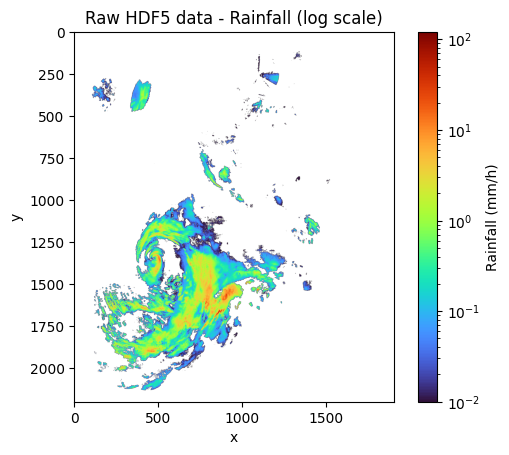

In [20]:
plt.figure()

plt.imshow(
    data_hdf5_plot, 
    origin="upper", # important !
    norm=log_norm,
    cmap="turbo",
    aspect="equal"
    ) 
    
plt.colorbar(label=plot_label)
plt.title(plot_title)
plt.xlabel("x")
plt.ylabel("y")

plt.show()

### Ajout des contours des continents sur le plot HDF5 (x,y) ---> PB Localisation dans la projection LAEA

In [21]:
print(lon0)

10.0


<class 'cartopy.crs.LambertAzimuthalEqualArea'>
+proj=laea +ellps=WGS84 +lon_0=10.0 +lat_0=55.0 +x_0=1950000.0 +y_0=-2100000.0 +no_defs +type=crs


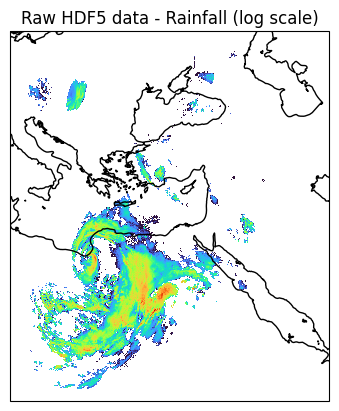

In [22]:
plt.figure()

# ATTENTION: crs.CRS.from_proj4() retourne souvent un objet pyproj-like encapsulé, 
# mais pas toujours une projection “Matplotlib-ready”.
#proj = ccrs.CRS.from_proj4(proj4) 

# MEILLEURE SOLUTION: reconstruire de la projection explicitement en Cartopy (sans passer par proj4)
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=lon0,
    central_latitude=lat0,
    false_easting=x0,
    false_northing=y0,
    globe=ccrs.Globe(ellipse=ellps)
)
#proj = ccrs.PlateCarree()

# CHECK
print(type(proj))
print(proj)

ax = plt.axes(projection=proj)

# ATTENTION: transform=proj ne marche que si x, y sont dans la même projection EXACTE
# si x, y = grille projetée LAEA → OK
# sinon lat/lon → il faut PlateCarree()
ax.pcolormesh(
    x, y, data_hdf5_plot,
    transform=proj,
    norm=log_norm,
    cmap="turbo"
)

ax.coastlines()

plt.title(plot_title)
plt.xlabel("x")
plt.ylabel("y")

plt.show()

## 3b - Plot du NetCDF en (x,y)

In [23]:
ds = xr.open_dataset(output_netcdf)
data_netcdf = ds[varname_out]

In [24]:
# éviter les valeurs nulles, négatives et les Nan
data_netcdf_plot = data_netcdf.where((data_netcdf > 0) & (data_netcdf != FILL))

In [25]:
#data_netcdf = data_plot.to_numpy()
data_netcdf_np = data_netcdf.to_numpy()

In [26]:
plot_label = f"{varname_out} (mm/h)"
plot_title = f"NetCDF data : Rainfall (log scale)"

diff_norm = colors.LogNorm(vmin=0.01, vmax=120)

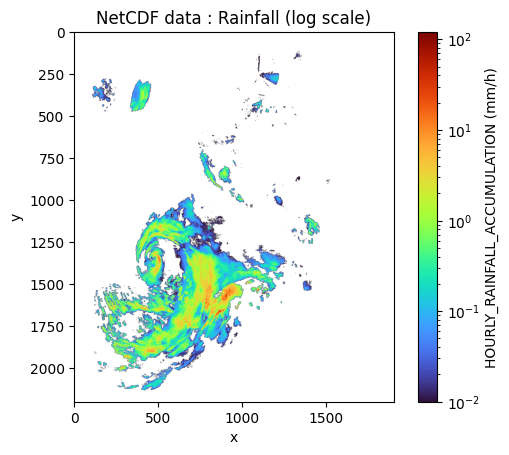

In [27]:
plt.figure()

plt.imshow(
    data_netcdf_plot, 
    origin="upper", # important !
    norm=diff_norm,
    cmap="turbo",
    aspect="equal"
     ) 

cbar = plt.colorbar()
cbar.set_label(plot_label)
plt.title(plot_title)
plt.xlabel("x")
plt.ylabel("y")
    
plt.show()

## 3b - Plot du NetCDF en (lon,lat)

In [28]:
lon = ds["lon"]
lat = ds["lat"]

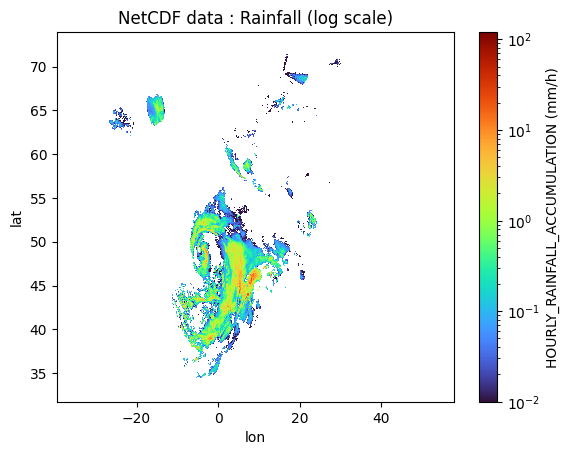

In [29]:
plt.figure()

plt.pcolormesh(
    lon, lat, data_netcdf_plot, 
    #origin="upper", # important !
    norm=log_norm,
    cmap="turbo",
    ) 

cbar = plt.colorbar()
cbar.set_label(plot_label)
plt.title(plot_title)
plt.xlabel("lon")
plt.ylabel("lat")
    
plt.show()

### Ajout des contours des contients sur le plot NetCDF (lon,lat)

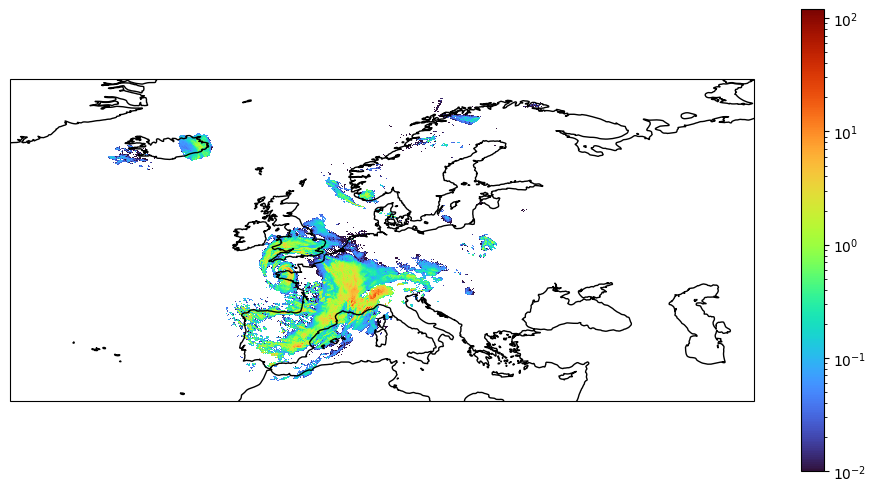

In [30]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=proj)

im = ax.pcolormesh(
    lon, lat, data_netcdf_plot,
    norm=log_norm,
    cmap="turbo",
    transform=proj)

ax.coastlines()
plt.colorbar(im)
    
plt.show()


## 3d - Plot diff (Netcdf - HDF5)

In [31]:
data_hdf5

array([[-9999000., -9999000., -9999000., ..., -9999000., -9999000.,
        -9999000.],
       [-9999000., -9999000., -9999000., ..., -9999000., -9999000.,
        -9999000.],
       [-9999000., -9999000., -9999000., ..., -9999000., -9999000.,
        -9999000.],
       ...,
       [-9999000., -9999000., -9999000., ..., -9999000., -9999000.,
        -9999000.],
       [-9999000., -9999000., -9999000., ..., -9999000., -9999000.,
        -9999000.],
       [-9999000., -9999000., -9999000., ..., -9999000., -9999000.,
        -9999000.]], shape=(2200, 1900))

In [32]:
data_netcdf_np

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2200, 1900), dtype=float32)

In [33]:
plot_label = f"{varname_out} (mm/h)"
plot_title = f"Diff (NETCDF - HDF5)"

diff_norm = colors.TwoSlopeNorm(vmin=-1.E-8, vcenter=0, vmax=+1.E-8)
#diff_norm = colors.TwoSlopeNorm(vmin=-1., vcenter=0, vmax=+1.)

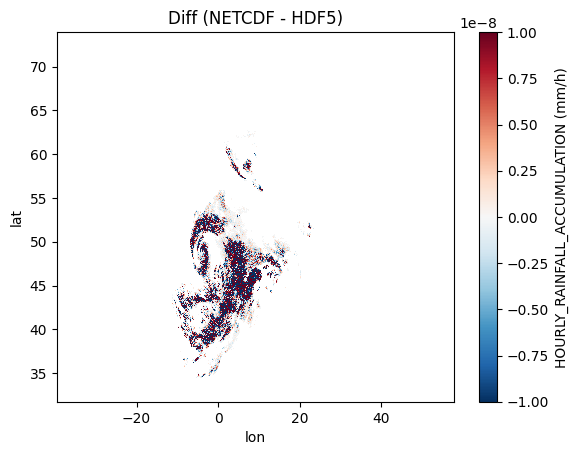

In [34]:
plt.figure()

data_diff = data_netcdf_np - data_hdf5

data_diff_plot = data_diff.astype(float)
data_diff_plot[(data_diff == 0)] = np.nan
#data_plot[(data <= 0) | (data == FILL)] = np.nan

m = plt.pcolormesh(
    lon, lat, data_diff_plot,
    cmap="RdBu_r",
    norm=diff_norm,
    shading="auto"
)

cbar = plt.colorbar()
cbar.set_label(plot_label)
plt.title(plot_title)
plt.xlabel("lon")
plt.ylabel("lat")
 
plt.show()

## 4 - Conversion NetCDF (toutes les échéances horaires du mois)

In [35]:
# utilisation des oordonnées lat/lon ou x/y
latlon_coords = True

# utilisation des lat/lon exactes fournies avec EURADCLIM
latlon_exact = True

# test seulement sur un échantillon du jeu de données
test = False

if not test:
    #list_of_fnames_in = sorted(glob.glob(f"{PROD}_{VAR}_{YEAR}{MONTH}*.h5"))
    lof = [f.name for f in Path(pi).glob(f"{PROD}_{VAR}_{YEAR}{MONTH}*.h5")]
    list_of_fnames_in = sorted(lof)
else:
    list_of_fnames_in = ["RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_201301231500.h5",
                         "RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_201301231600.h5", 
                         "RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_201301231700.h5",
                         "RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_201301231800.h5",]
    # Date     Time   Level Gridsize    Miss :     Minimum        Mean     Maximum : Parameter name
    # 2013-01-23 15:00:00       0  4180000 2303746 :      0.0000    0.072746      120.95 : HOURLY_RAINFALL_ACCUMULATION
    # 2013-01-23 16:00:00       0  4180000 2447877 :      0.0000    0.063897      43.181 : HOURLY_RAINFALL_ACCUMULATION
    # 2013-01-23 17:00:00       0  4180000 2298585 :      0.0000    0.086475      181.40 : HOURLY_RAINFALL_ACCUMULATION
    # 2013-01-23 18:00:00       0  4180000 2413985 :      0.0000    0.086906      132.90 : HOURLY_RAINFALL_ACCUMULATION

# -------------------------
# 1. Lecture HDF5
# -------------------------

# Nom de la variable d'entrée (HDF5) = nom générique
varname_in = "variable"
varname_out = VAR

data_list = []
time_list = []

for fname_in in list_of_fnames_in:
    
    print(fname_in)
    
    # time from filename
    timestamp = fname_in.split("_")[-1].replace(".h5", "")
    time = pd.to_datetime(timestamp, format="%Y%m%d%H%M")
    
    input_hdf5 = '/'.join([path_in, fname_in])
    
    with h5py.File(input_hdf5, "r") as f:
        data = f["dataset1/data1/data"][:]
        where = dict(f["where"].attrs)
    ###print(where)

    # gestion des Nan
    fill = -9.9990e+06
    data = data.astype("float32")
    data[data == fill] = np.nan
    
    # Création d'une variable time au standard
    time = pd.to_datetime(timestamp, format="%Y%m%d%H%M")
    
    # increment de la série temporelle
    #d = da.from_array(data, chunks=(200, 200))  # à adapter
    data_list.append(data)
    time_list.append(time)
        
# -------------------------
# 2. stack time
# -------------------------

data_stack = da.stack(data_list, axis=0)

#nt, ny, nx = data_stack.shape


# -------------------------
# 3. Grille
# -------------------------

# ajuster si besoin après test visuel
# data = data[::-1, :]
# y = y[::-1]

# -------------------------
# 4. Projection → lat/lon
# -------------------------

if latlon_exact:
    lon = copy.deepcopy(lon_exact)
    lat = copy.deepcopy(lat_exact)  
else:
    lon = copy.deepcopy(lon_rebuilt)
    lat = copy.deepcopy(lat_rebuilt)

# -------------------------
# 5. Dataset xarray
# -------------------------

if latlon_coords:     
    ds = xr.Dataset(
        data_vars=dict(
            variable=(("time", "y", "x"), data_stack)
         ),
        coords=dict(
             time=("time", time_list),
             lon=(("y", "x"), lon),
             lat=(("y", "x"), lat),
         ),
      )
else:
    ds = xr.Dataset(
        data_vars=dict(
             variable=(("y", "x"), data)
        ),
        coords=dict(
            time=("time", [time]),
            x=("x", x),
            y=("y", y),
        ),
    )

# -------------------------
# 5. Attributs CF
# -------------------------

if latlon_coords:  
    ds["lon"].attrs = {
        "standard_name": "longitude",
        "units": "degrees_east"
    }

    ds["lat"].attrs = {
         "standard_name": "latitude",
         "units": "degrees_north"
     }
else:
    ds["x"].attrs = {
         "standard_name": "projection_x_coordinate",
         "units": "m"
    }
    
    ds["y"].attrs = {
         "standard_name": "projection_y_coordinate",
         "units": "m"
     }


CF_VARIABLES = {
      "HOURLY_RAINFALL_ACCUMULATION": {
         "standard_name": "lwe_thickness_of_precipitation_amount",
         "long_name": "Hourly accumulated rainfall",
         "units": "kg m-2",
         "grid_mapping": "crs",
         "coordinates": "lat lon"
     }
}

ds = ds.rename({varname_in: varname_out})

attrs = CF_VARIABLES[varname_out]

ds[varname_out].attrs.update(attrs)

# -------------------------
# 6. CRS
# -------------------------

ds["crs"] = xr.DataArray()
ds["crs"].attrs = {
     "grid_mapping_name": "lambert_azimuthal_equal_area",
    "spatial_ref": proj4
}

# -------------------------
# 7. Export
# -------------------------

ds.to_netcdf(output_netcdf_ts, format="NETCDF4",
    #encoding={
    #    varname_out: {"zlib": True, "complevel": 4, "chunksizes": (1, ny, nx)}
    #    varname_out: {"zlib": True, "complevel": 4}
    #}
)

RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010700.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010010900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010011700.h5
RAD_OPERA_

RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010070500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010070600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010070700.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010070800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010070900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071700.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010071900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010072000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010072100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010072200.h5
RAD_OPERA_

RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131700.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010131900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010132000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010132100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010132200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010132300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010140000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010140100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010140200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010140300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010140400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010140500.h5
RAD_OPERA_

RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010191800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010191900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010192000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010192100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010192200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010192300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200700.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010200900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010201000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010201100.h5
RAD_OPERA_

RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260700.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260800.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010260900.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261000.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261100.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261200.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261300.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261400.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261500.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261600.h5
RAD_OPERA_HOURLY_RAINFALL_ACCUMULATION_202010261700.h5
RAD_OPERA_

## 4a - Plot carte d'une échéance temporelle (toujour la même pour vérif)

In [36]:
plot_label = "Rainfall (mm/h)"
plot_title = "Raw HDF5 data : Rainfall (log scale)"
log_norm = colors.LogNorm(vmin=0.01, vmax=120)

<Figure size 640x480 with 0 Axes>

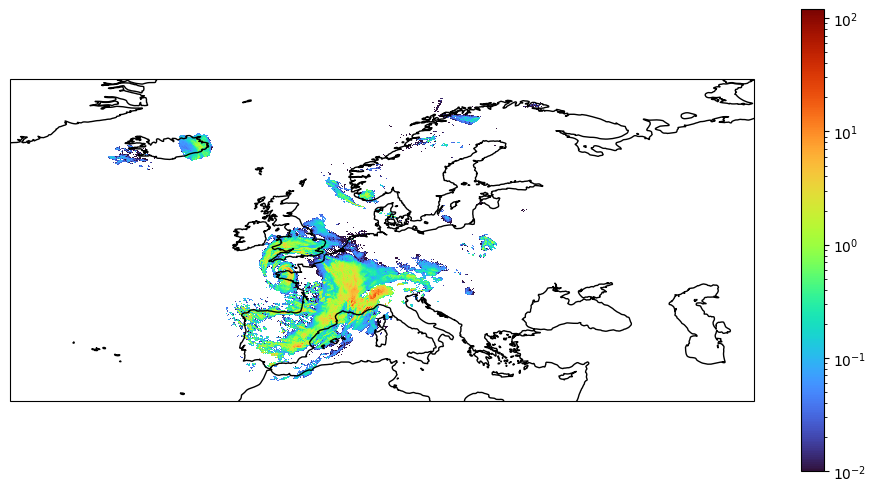

In [37]:
ds = xr.open_dataset(output_netcdf_ts)

data = ds[varname_out].sel(time=ECHEANCE)

plt.figure()

# éviter les valeurs nulles, négatives et les Nan
data_plot = data.where((data > 0) & (data != FILL))

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=proj)

im = ax.pcolormesh(
    lon, lat, data_netcdf_plot,
    norm=log_norm,
    cmap="turbo",
    transform=proj)

ax.coastlines()
plt.colorbar(im)
    
plt.show()

## 4b - Plot série temporelle de la moyenne spatiale

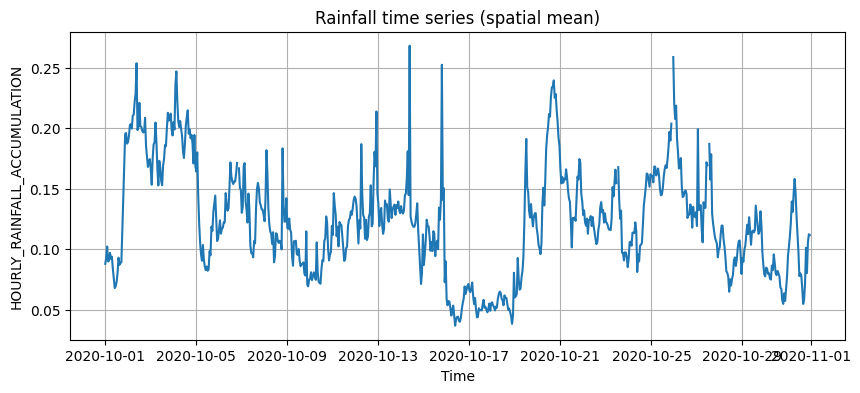

In [38]:
ds = xr.open_dataset(output_netcdf_ts)

# moyenne spatiale
ts = ds[varname_out].mean(dim=["y", "x"])

plt.figure(figsize=(10,4))
plt.plot(ds["time"], ts)

plt.title("Rainfall time series (spatial mean)")
plt.xlabel("Time")
plt.ylabel(varname_out)
plt.grid()
plt.show()